In [ ]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
# ============================================================
# 2. LOAD DATA
# ============================================================

In [3]:
df = pd.read_excel("PJMW_MW_Hourly.xlsx")

print("Dataset Shape:", df.shape)

df.head()



Dataset Shape: (143206, 2)


,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930


In [4]:

# ============================================================
# 3. Basic Dataset Exploration
# ============================================================

In [5]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (143206, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB

Statistical Summary:


,Datetime,PJMW_MW
count,143206,143206.000000
mean,2010-06-02 03:39:50.656816128,5602.375089
min,2002-04-01 01:00:00,487.000000
25%,2006-05-02 03:15:00,4907.000000
50%,2010-06-02 04:30:00,5530.000000
75%,2014-07-03 06:45:00,6252.000000
max,2018-08-03 00:00:00,9594.000000
std,NaN,979.142872


In [6]:
# ============================================================
# 4. Missing Values and Duplicates
# ============================================================

In [7]:

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("Duplicate Datetime values:", df["Datetime"].duplicated().sum())

Missing values:
Datetime    0
PJMW_MW     0
dtype: int64

Duplicate rows: 0
Duplicate Datetime values: 4


In [8]:
# ============================================================
# 5. Date Range
# ============================================================

In [9]:
print("Starting Date:", df["Datetime"].min())
print("Ending Date:", df["Datetime"].max())

expected_hours = int(
    (df["Datetime"].max() - df["Datetime"].min()).total_seconds() / 3600
) + 1

actual_hours = len(df)

print("\nExpected hours:", expected_hours)
print("Actual rows:", actual_hours)
print("Difference:", expected_hours - actual_hours)

Starting Date: 2002-04-01 01:00:00
Ending Date: 2018-08-03 00:00:00

Expected hours: 143232
Actual rows: 143206
Difference: 26


In [10]:
# ============================================================
# 6. Arrange Data Chronologically
# ============================================================


In [11]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

df = (
    df.sort_values("Datetime")
      .reset_index(drop=True)
)

print(df.head())
print(df.tail())

             Datetime  PJMW_MW
0 2002-04-01 01:00:00     4374
1 2002-04-01 02:00:00     4306
2 2002-04-01 03:00:00     4322
3 2002-04-01 04:00:00     4359
4 2002-04-01 05:00:00     4436
                  Datetime  PJMW_MW
143201 2018-08-02 20:00:00     6545
143202 2018-08-02 21:00:00     6496
143203 2018-08-02 22:00:00     6325
143204 2018-08-02 23:00:00     5892
143205 2018-08-03 00:00:00     5489


In [12]:
# ============================================================
# 7. Time-Series Plot
# ============================================================

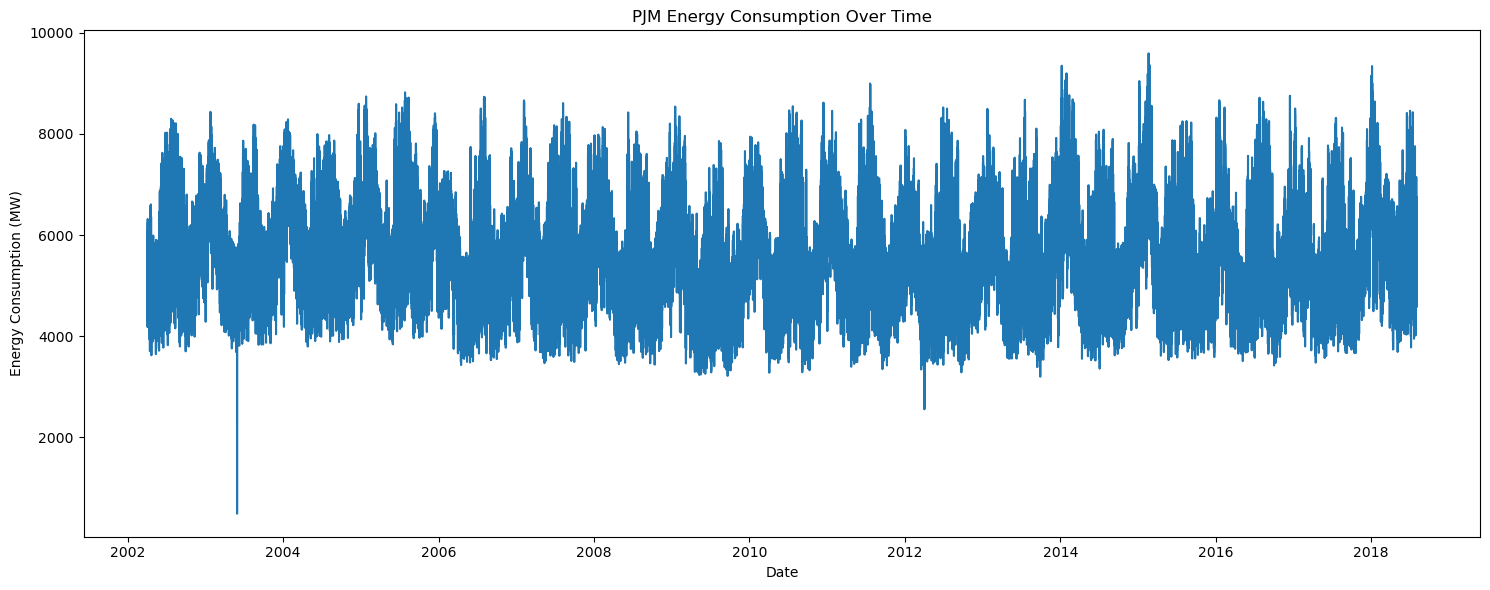

In [13]:
plt.figure(figsize=(15, 6))

plt.plot(df["Datetime"], df["PJMW_MW"])

plt.title("PJM Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 8.Box Plot
# ============================================================

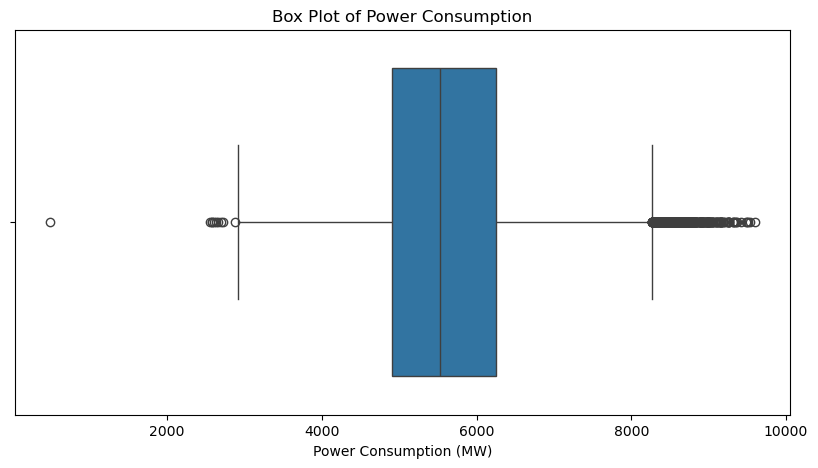

Minimum consumption: 487


In [15]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["PJMW_MW"])

plt.title("Box Plot of Power Consumption")
plt.xlabel("Power Consumption (MW)")

plt.show()

print("Minimum consumption:", df["PJMW_MW"].min())

In [16]:
# ============================================================
# Handle the Extreme Minimum Value
# ============================================================

In [17]:
# Replace the extreme minimum value with NaN

min_value = df["PJMW_MW"].min()

df.loc[
    df["PJMW_MW"] == min_value,
    "PJMW_MW"
] = np.nan

print("Missing values after replacing extreme minimum:")
print(df["PJMW_MW"].isnull().sum())

Missing values after replacing extreme minimum:
1


In [18]:
# ============================================================
# 8. HANDLE EXTREME MINIMUM VALUE
# ============================================================

In [19]:
# Replace the extreme minimum value with NaN
min_value = df["PJMW_MW"].min()

In [20]:
# ============================================================
# Time-Based Feature Engineering
# ============================================================

In [21]:
df["Year"] = df["Datetime"].dt.year
df["Month"] = df["Datetime"].dt.month
df["Day"] = df["Datetime"].dt.day
df["Hour"] = df["Datetime"].dt.hour
df["Day_of_Week"] = df["Datetime"].dt.day_name()

df.head()

,Datetime,PJMW_MW,Year,Month,Day,Hour,Day_of_Week
0,2002-04-01 01:00:00,4374.0,2002,4,1,1,Monday
1,2002-04-01 02:00:00,4306.0,2002,4,1,2,Monday
2,2002-04-01 03:00:00,4322.0,2002,4,1,3,Monday
3,2002-04-01 04:00:00,4359.0,2002,4,1,4,Monday
4,2002-04-01 05:00:00,4436.0,2002,4,1,5,Monday


In [22]:
# ============================================================
# Fill the Invalid Consumption Value
# ============================================================

In [23]:
# Calculate average consumption for each hour of the day

hourly_consumption = (
    df.groupby("Hour")["PJMW_MW"]
      .mean()
)

print(hourly_consumption)

# Use the average consumption at hour 0
replacement_value = hourly_consumption.loc[0]

print("\nReplacement value:", replacement_value)

# Fill the missing value
df["PJMW_MW"] = df["PJMW_MW"].fillna(replacement_value)

print("\nRemaining missing values:")
print(df["PJMW_MW"].isnull().sum())

Hour
0     5231.163426
1     4940.489276
2     4779.152349
3     4697.121996
4     4672.537366
5     4734.933479
6     4958.209450
7     5323.434316
8     5571.168398
9     5708.667058
10    5818.219169
11    5904.120476
12    5947.523794
13    5959.946716
14    5970.935824
15    5953.164712
16    5957.636394
17    6031.231233
18    6158.806803
19    6199.285355
20    6183.568365
21    6152.210121
22    5982.300436
23    5618.226206
Name: PJMW_MW, dtype: float64

Replacement value: 5231.163426081126

Remaining missing values:
0


Explanation:
The invalid value is replaced using an hourly consumption value rather than an arbitrary constant.

Small improvement: For a production-quality project, we could use interpolation or a more local imputation method, but your current approach is acceptable for this project.

In [24]:
# ============================================================
# Verify Cleaning
# ============================================================

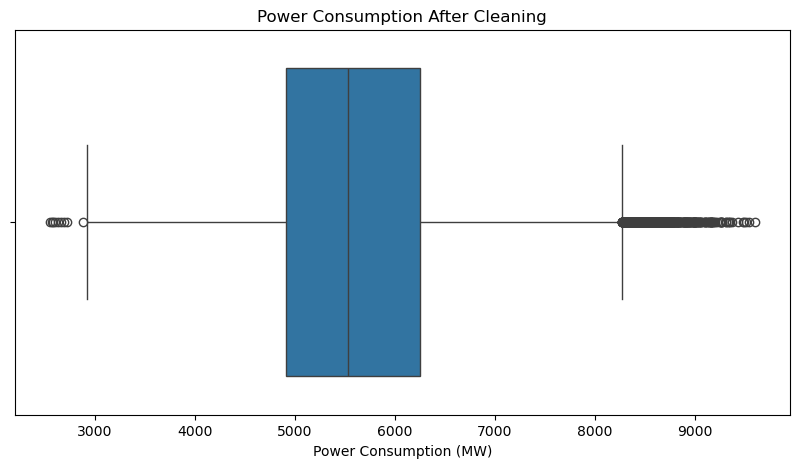

In [25]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["PJMW_MW"])

plt.title("Power Consumption After Cleaning")
plt.xlabel("Power Consumption (MW)")

plt.show()


In [26]:
# ============================================================
# Cleaned Time-Series Plot
# ============================================================

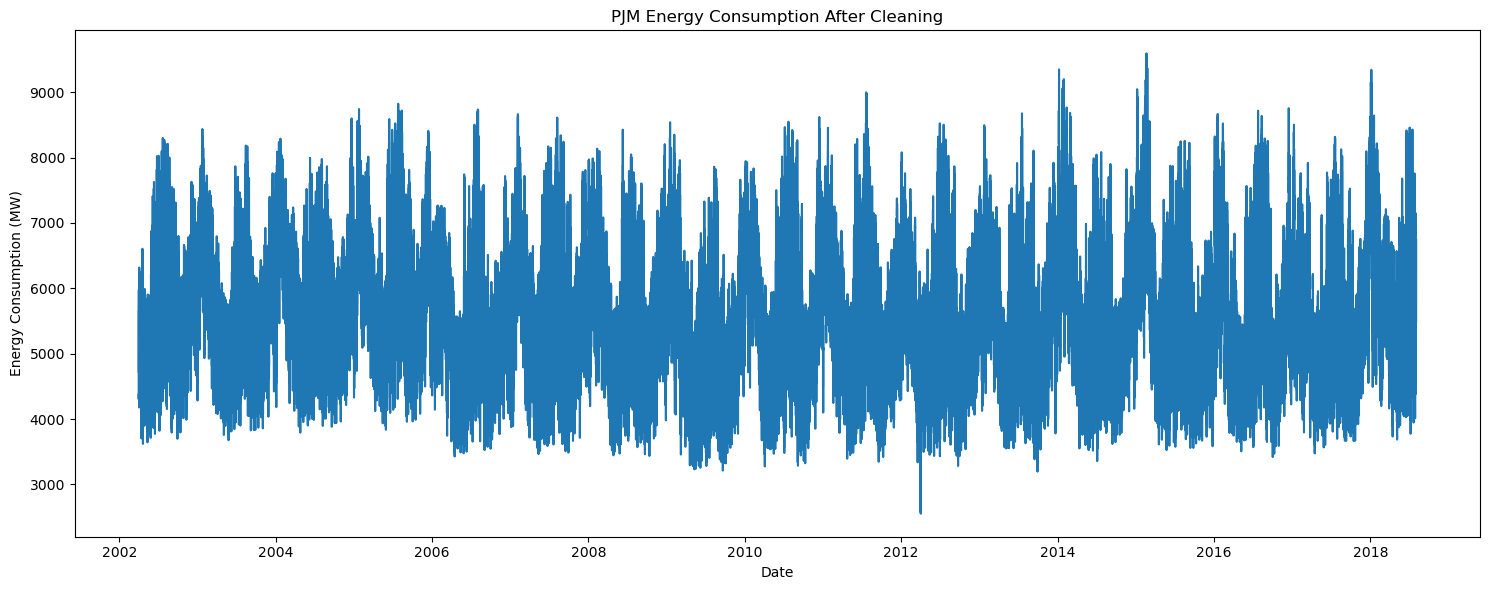

In [27]:
plt.figure(figsize=(15, 6))

plt.plot(df["Datetime"], df["PJMW_MW"])

plt.title("PJM Energy Consumption After Cleaning")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")

plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# Average Consumption by Hour
# ============================================================

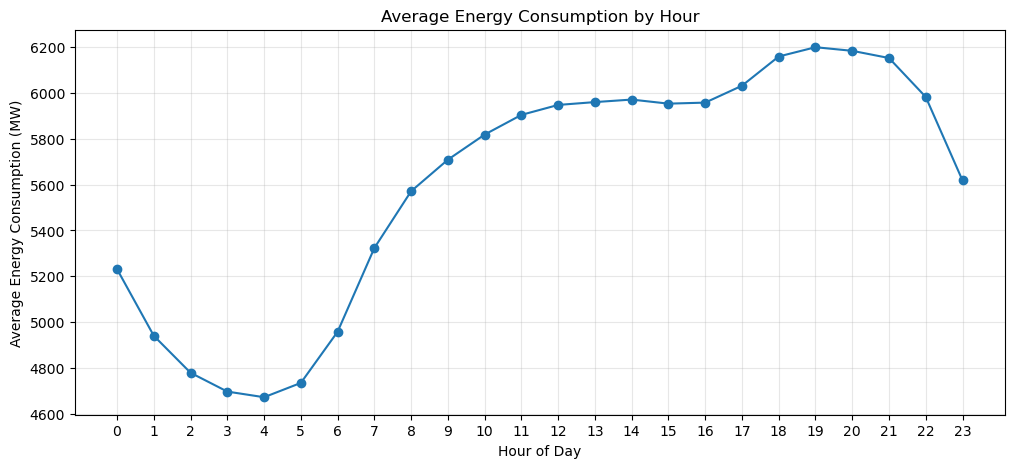

In [29]:
hourly_consumption = (
    df.groupby("Hour")["PJMW_MW"]
      .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_consumption.index,
    hourly_consumption.values,
    marker="o"
)

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Consumption (MW)")

plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

In [30]:
# ============================================================
# Average Consumption by Month
# ============================================================

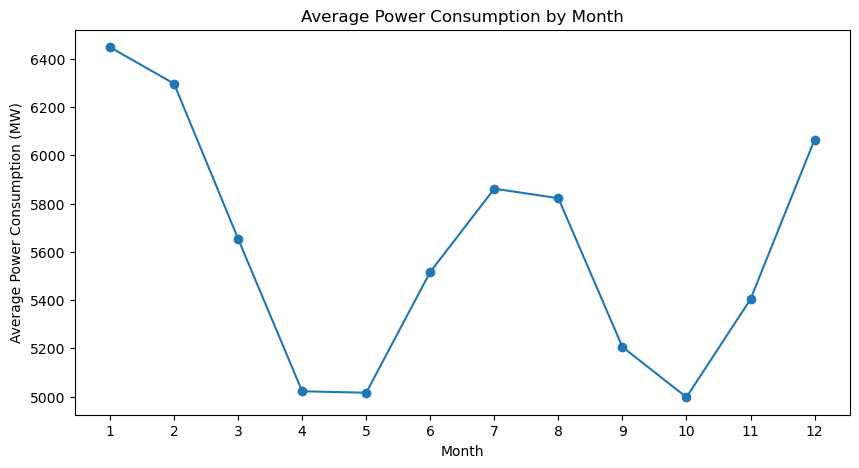

In [31]:
monthly_data = (
    df.groupby("Month")["PJMW_MW"]
      .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_data.index,
    monthly_data.values,
    marker="o"
)

plt.title("Average Power Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Power Consumption (MW)")

plt.xticks(range(1, 13))

plt.show()

In [32]:
# ============================================================
# Average Consumption by Day
# ============================================================

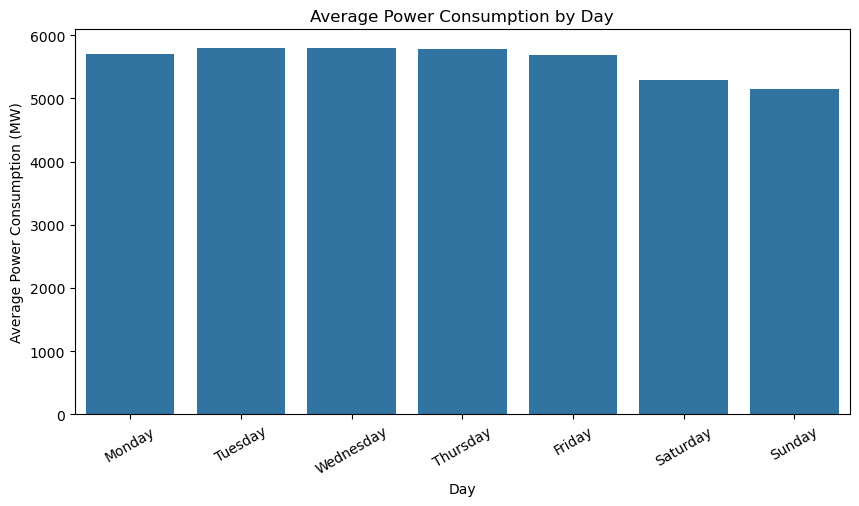

In [33]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_data = (
    df.groupby("Day_of_Week")["PJMW_MW"]
      .mean()
      .reindex(day_order)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=weekly_data.index,
    y=weekly_data.values
)

plt.title("Average Power Consumption by Day")
plt.xlabel("Day")
plt.ylabel("Average Power Consumption (MW)")

plt.xticks(rotation=30)

plt.show()

In [34]:
# ============================================================
# Create Season Feature
# ============================================================

In [35]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Other"


df["Season"] = df["Month"].apply(get_season)

df[["Month", "Season"]].head()

,Month,Season
0,4,Other
1,4,Other
2,4,Other
3,4,Other
4,4,Other


In [36]:
# ============================================================
# Seasonal Analysis
# ============================================================

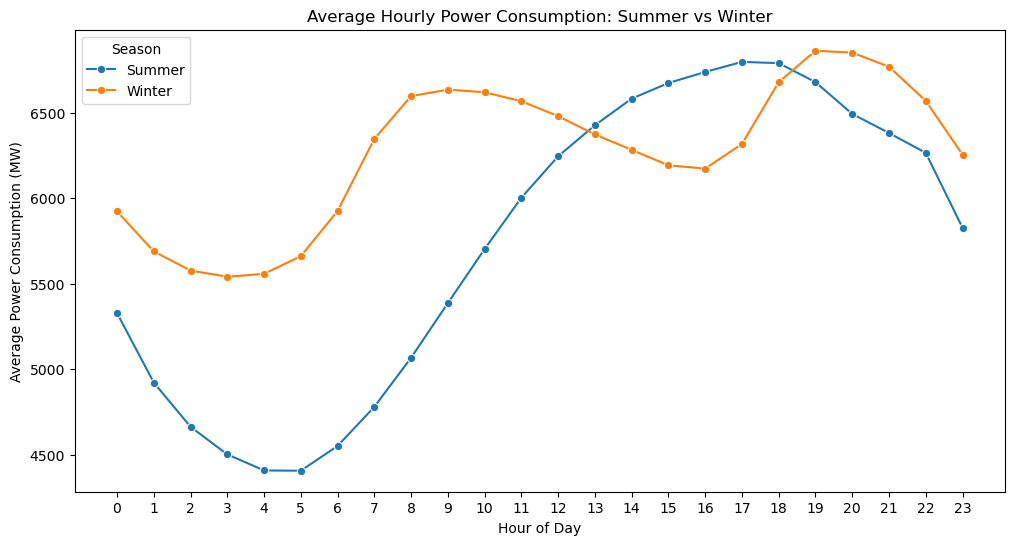

In [37]:
df_seasons = df[
    df["Season"].isin(["Summer", "Winter"])
]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_seasons,
    x="Hour",
    y="PJMW_MW",
    hue="Season",
    errorbar=None,
    marker="o"
)

plt.title("Average Hourly Power Consumption: Summer vs Winter")
plt.xlabel("Hour of Day")
plt.ylabel("Average Power Consumption (MW)")
plt.xticks(range(24))

plt.show()

In [38]:
# ============================================================
# Seasonal Distribution
# ============================================================

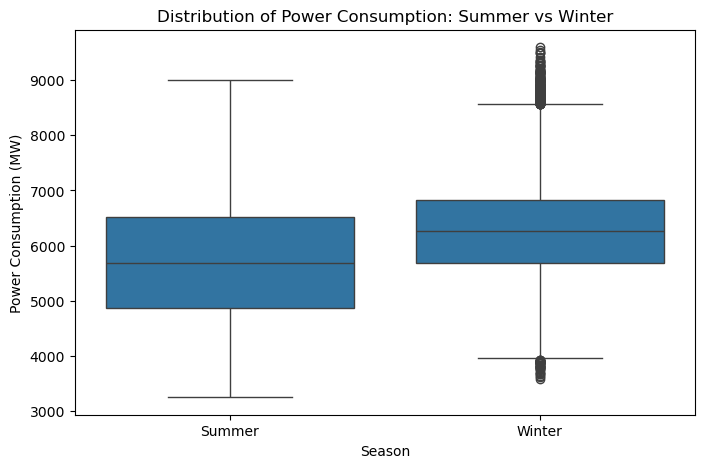

          count         mean          std     min     25%     50%     75%  \
Season                                                                      
Summer  36841.0  5734.206129  1077.573497  3255.0  4872.0  5688.0  6526.0   
Winter  34655.0  6268.813851   848.264651  3585.0  5681.0  6258.0  6834.0   

           max  
Season          
Summer  8998.0  
Winter  9594.0  


In [39]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_seasons,
    x="Season",
    y="PJMW_MW"
)

plt.title("Distribution of Power Consumption: Summer vs Winter")
plt.ylabel("Power Consumption (MW)")

plt.show()

print(
    df_seasons.groupby("Season")["PJMW_MW"]
    .describe()
)

In [40]:
# ============================================================
# Daily Resampling
# ============================================================

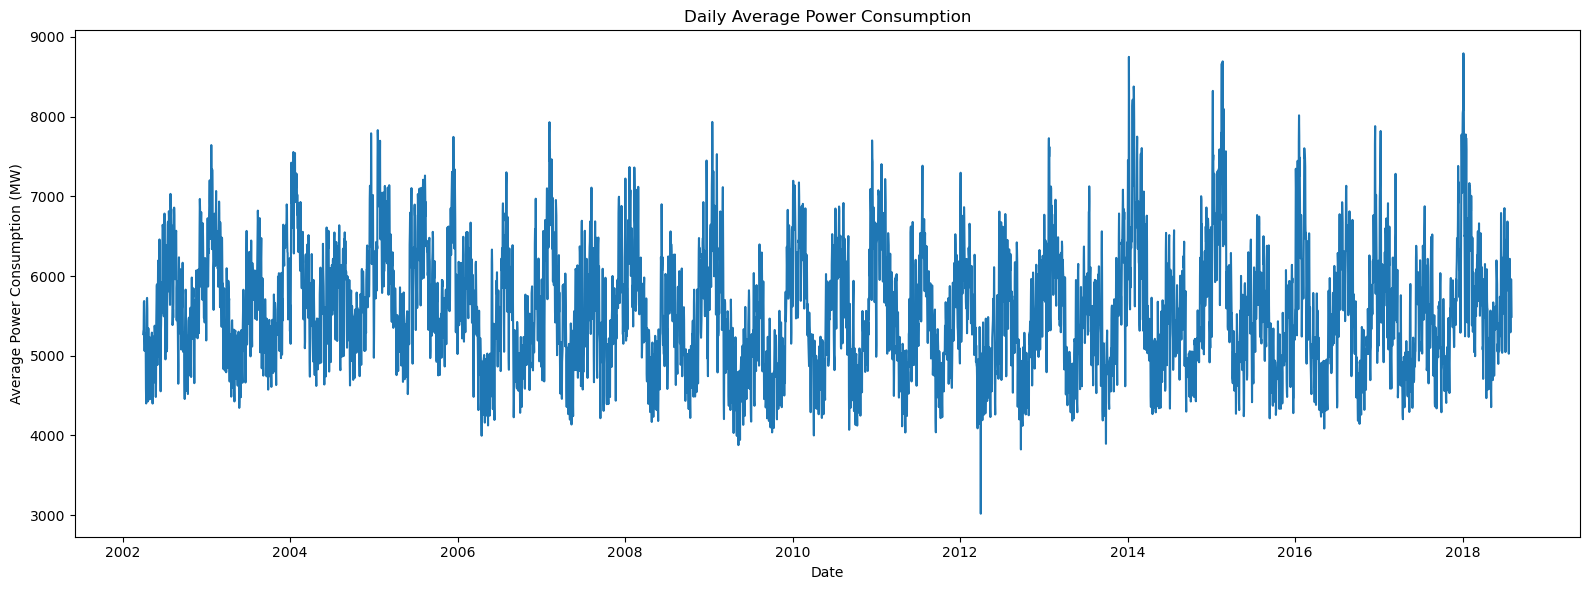

In [41]:
daily_data = (
    df.set_index("Datetime")["PJMW_MW"]
      .resample("D")
      .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(daily_data)

plt.title("Daily Average Power Consumption")
plt.xlabel("Date")
plt.ylabel("Average Power Consumption (MW)")

plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# weekly Resampling
# ============================================================

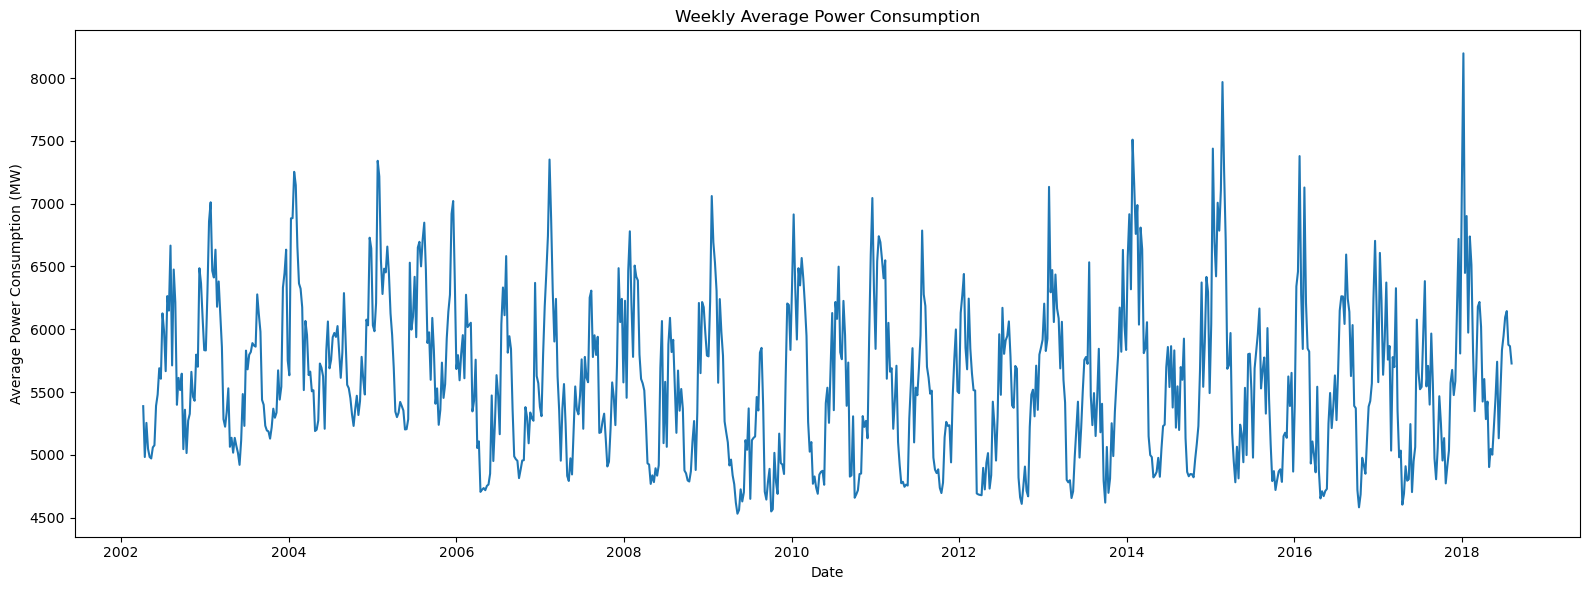

In [ ]:
weekly_resampled = (
    df.set_index("Datetime")["PJMW_MW"]
      .resample("W")
      .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(weekly_resampled)

plt.title("Weekly Average Power Consumption")
plt.xlabel("Date")
plt.ylabel("Average Power Consumption (MW)")

plt.tight_layout()
plt.show()

In [44]:
# ============================================================
# Monthly Resampling
# ============================================================

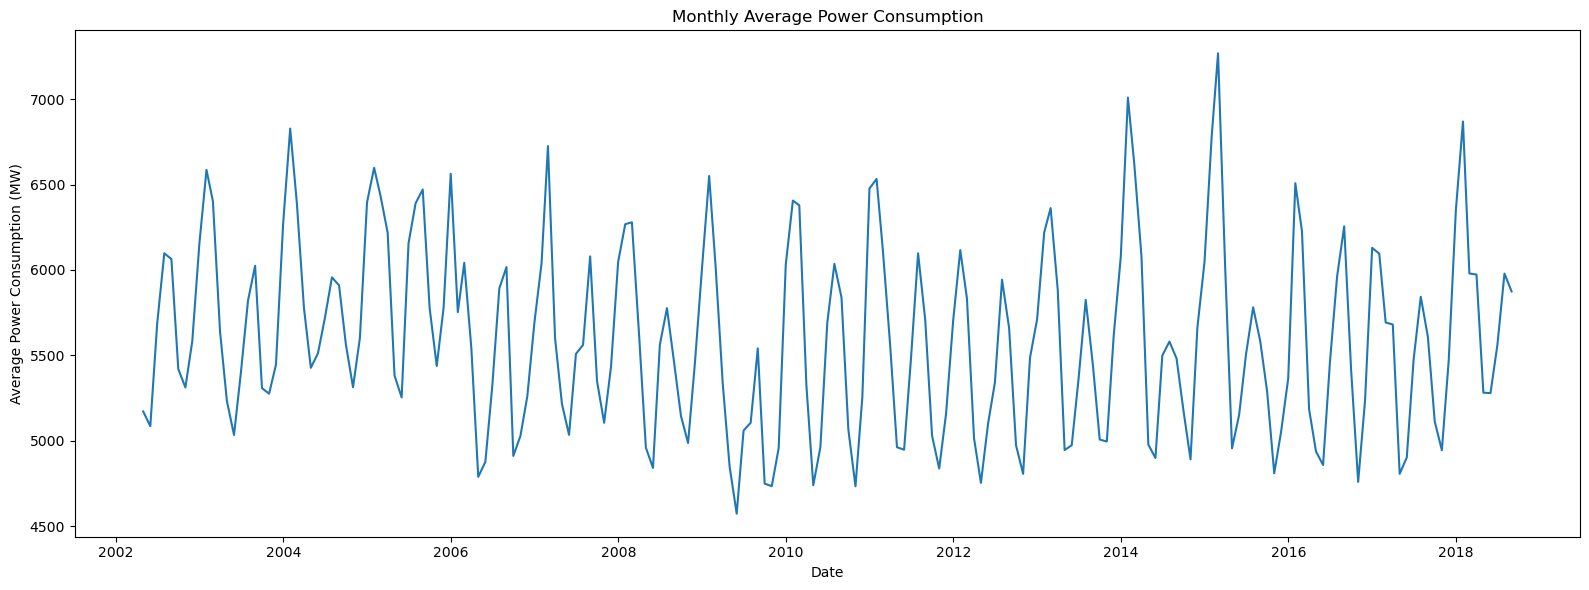

In [45]:
monthly_resampled = (
    df.set_index("Datetime")["PJMW_MW"]
      .resample("ME")
      .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(monthly_resampled)

plt.title("Monthly Average Power Consumption")
plt.xlabel("Date")
plt.ylabel("Average Power Consumption (MW)")

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# Create Lag Features
# ============================================================

In [47]:
df["lag_1"] = df["PJMW_MW"].shift(1)
df["lag_24"] = df["PJMW_MW"].shift(24)
df["lag_168"] = df["PJMW_MW"].shift(168)
df["lag_720"] = df["PJMW_MW"].shift(720)

df[
    [
        "PJMW_MW",
        "lag_1",
        "lag_24",
        "lag_168",
        "lag_720"
    ]
].head(10)

,PJMW_MW,lag_1,lag_24,lag_168,lag_720
0,4374.0,NaN,NaN,NaN,NaN
1,4306.0,4374.0,NaN,NaN,NaN
2,4322.0,4306.0,NaN,NaN,NaN
3,4359.0,4322.0,NaN,NaN,NaN
4,4436.0,4359.0,NaN,NaN,NaN
5,4723.0,4436.0,NaN,NaN,NaN
6,5180.0,4723.0,NaN,NaN,NaN
7,5482.0,5180.0,NaN,NaN,NaN
8,5616.0,5482.0,NaN,NaN,NaN
9,5722.0,5616.0,NaN,NaN,NaN


In [48]:
# ============================================================
# Correlation Analysis
# ============================================================

In [49]:
correlation = (
    df.corr(numeric_only=True)["PJMW_MW"]
      .sort_values()
)

print(correlation)

Month     -0.152441
Year      -0.046988
Day       -0.006121
Hour       0.447225
lag_720    0.507029
lag_168    0.759379
lag_24     0.877276
lag_1      0.974818
PJMW_MW    1.000000
Name: PJMW_MW, dtype: float64


In [50]:
# ============================================================
# Remove Rows With Missing Lag Values
# ============================================================

In [51]:
df = df.dropna(
    subset=[
        "lag_1",
        "lag_24",
        "lag_168",
        "lag_720"
    ]
).reset_index(drop=True)

print("Dataset shape after lag creation:")
print(df.shape)

print("\nMissing values in lag features:")
print(
    df[
        [
            "lag_1",
            "lag_24",
            "lag_168",
            "lag_720"
        ]
    ].isnull().sum()
)

Dataset shape after lag creation:
(142486, 12)

Missing values in lag features:
lag_1      0
lag_24     0
lag_168    0
lag_720    0
dtype: int64


Explanation:
The first 720 rows don't have enough historical information to calculate lag_720, so they are removed rather than artificially filled.

In [52]:
# ============================================================
# One-Hot Encoding
# ============================================================

In [53]:
df = pd.get_dummies(
    df,
    columns=["Day_of_Week", "Season"],
    dtype=int
)

df.head()

,Datetime,PJMW_MW,Year,Month,Day,Hour,lag_1,lag_24,lag_168,lag_720,Day_of_Week_Friday,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday,Season_Other,Season_Summer,Season_Winter
0,2002-05-01 02:00:00,4418.0,2002,5,1,2,4503.0,4599.0,4738.0,4374.0,0,0,0,0,0,0,1,1,0,0
1,2002-05-01 03:00:00,4310.0,2002,5,1,3,4418.0,4528.0,4711.0,4306.0,0,0,0,0,0,0,1,1,0,0
2,2002-05-01 04:00:00,4282.0,2002,5,1,4,4310.0,4555.0,4743.0,4322.0,0,0,0,0,0,0,1,1,0,0
3,2002-05-01 05:00:00,4431.0,2002,5,1,5,4282.0,4654.0,4912.0,4359.0,0,0,0,0,0,0,1,1,0,0
4,2002-05-01 06:00:00,4732.0,2002,5,1,6,4431.0,4940.0,5255.0,4436.0,0,0,0,0,0,0,1,1,0,0


Explanation:
Machine-learning models require categorical variables such as day names and seasons to be converted into numerical columns.

In [54]:
# ============================================================
# Define Features and Target
# ============================================================

In [55]:
features = [
    "lag_1",
    "lag_24",
    "lag_168",
    "lag_720",
    "Hour",
    "Month",
    "Year",
    "Day_of_Week_Monday",
    "Day_of_Week_Tuesday",
    "Day_of_Week_Wednesday",
    "Day_of_Week_Thursday",
    "Day_of_Week_Friday",
    "Day_of_Week_Saturday",
    "Day_of_Week_Sunday",
    "Season_Summer",
    "Season_Winter",
    "Season_Other"
]

X = df[features]
y = df["PJMW_MW"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (142486, 17)
y shape: (142486,)


In [56]:
# ============================================================
# Train-Test Split
# ============================================================

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining period:")
print(df["Datetime"].iloc[:len(X_train)].min())
print(df["Datetime"].iloc[:len(X_train)].max())

print("\nTesting period:")
print(df["Datetime"].iloc[len(X_train):].min())
print(df["Datetime"].iloc[len(X_train):].max())

Training samples: 113988
Testing samples : 28498

Training period:
2002-05-01 02:00:00
2015-05-03 14:00:00

Testing period:
2015-05-03 15:00:00
2018-08-03 00:00:00


Explanation:
shuffle=False is essential for time-series forecasting. The model trains on the past and is evaluated on the future.

In [58]:
# ============================================================
# Linear Regression
# ============================================================

In [59]:
model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("---------------------------")
print(f"MAE  : {mae_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")

Linear Regression
---------------------------
MAE  : 155.1054
RMSE : 196.1857
R²   : 0.9611


In [60]:
# ============================================================
# Random Forest
# ============================================================

In [61]:
model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("---------------------------")
print(f"MAE  : {mae_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest
---------------------------
MAE  : 60.5617
RMSE : 79.7117
R²   : 0.9936


In [62]:
# ============================================================
# XGBoost
# ============================================================

In [63]:
model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("---------------------------")
print(f"MAE  : {mae_xgb:.4f}")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"R²   : {r2_xgb:.4f}")

XGBoost
---------------------------
MAE  : 61.0831
RMSE : 81.4038
R²   : 0.9933


In [64]:
import joblib

joblib.dump(model_xgb, "pjm_xgboost_model.pkl")

['pjm_xgboost_model.pkl']

In [65]:
joblib.dump(features, "xgb_features.pkl")

['xgb_features.pkl']

In [68]:
# ============================================================
# ANN
# ============================================================

In [75]:


data = df["PJMW_MW"].values.reshape(-1, 1)

split_raw = int(len(data) * 0.8)

train_data = data[:split_raw]
test_data = data[split_raw:]

scaler_lstm = MinMaxScaler()

train_scaled = scaler_lstm.fit_transform(train_data)
test_scaled = scaler_lstm.transform(test_data)

sequence_length = 24

X_train_lstm = []
y_train_lstm = []

for i in range(sequence_length, len(train_scaled)):
    X_train_lstm.append(train_scaled[i-sequence_length:i])
    y_train_lstm.append(train_scaled[i])

X_test_lstm = []
y_test_lstm = []

for i in range(sequence_length, len(test_scaled)):
    X_test_lstm.append(test_scaled[i-sequence_length:i])
    y_test_lstm.append(test_scaled[i])

X_train_lstm = np.array(X_train_lstm)
y_train_lstm = np.array(y_train_lstm)

X_test_lstm = np.array(X_test_lstm)
y_test_lstm = np.array(y_test_lstm)

print("X_train:", X_train_lstm.shape)
print("X_test:", X_test_lstm.shape)

X_train: (113964, 24, 1)
X_test: (28474, 24, 1)


In [70]:
# ============================================================
# ANN Loss Curve
# ============================================================

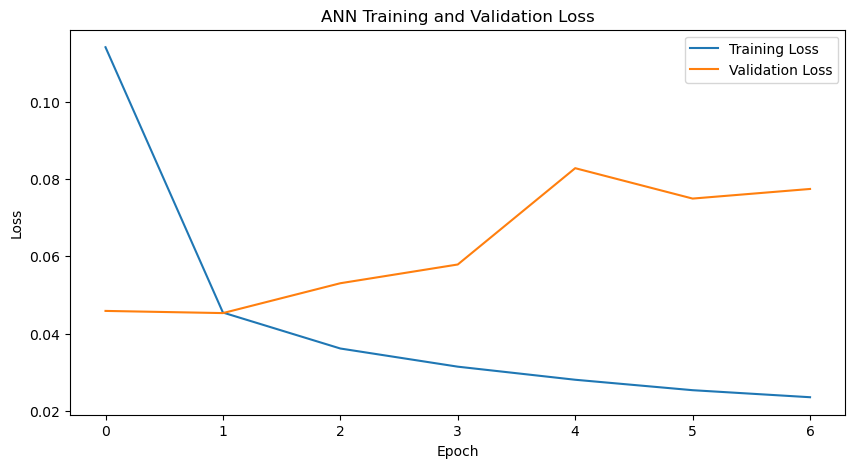

In [71]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_ann.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_ann.history["val_loss"],
    label="Validation Loss"
)

plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [76]:
# ============================================================
# LSTM
# ============================================================

In [73]:
# ---------------------------------------------------------
# Prepare target
# ---------------------------------------------------------

data = df["PJMW_MW"].values.reshape(-1, 1)

# ---------------------------------------------------------
# Train-test split first
# ---------------------------------------------------------

split_raw = int(len(data) * 0.8)

train_data = data[:split_raw]
test_data = data[split_raw:]

# ---------------------------------------------------------
# Scale using training data only
# ---------------------------------------------------------

scaler_lstm = MinMaxScaler()

train_scaled = scaler_lstm.fit_transform(train_data)
test_scaled = scaler_lstm.transform(test_data)

# ---------------------------------------------------------
# Create sequences
# ---------------------------------------------------------

sequence_length = 24

X_train_lstm = []
y_train_lstm = []

for i in range(sequence_length, len(train_scaled)):
    X_train_lstm.append(
        train_scaled[i-sequence_length:i]
    )
    y_train_lstm.append(
        train_scaled[i]
    )

X_test_lstm = []
y_test_lstm = []

for i in range(sequence_length, len(test_scaled)):
    X_test_lstm.append(
        test_scaled[i-sequence_length:i]
    )
    y_test_lstm.append(
        test_scaled[i]
    )

X_train_lstm = np.array(X_train_lstm)
y_train_lstm = np.array(y_train_lstm)

X_test_lstm = np.array(X_test_lstm)
y_test_lstm = np.array(y_test_lstm)

print("X_train LSTM:", X_train_lstm.shape)
print("X_test LSTM :", X_test_lstm.shape)

X_train LSTM: (113964, 24, 1)
X_test LSTM : (28474, 24, 1)


In [74]:
# ============================================================
# Build and Train LSTM
# ============================================================

In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

model_lstm = Sequential([
    Input(shape=(24, 1)),

    LSTM(64, return_sequences=True),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dense(1)
])

model_lstm.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stop_lstm = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop_lstm],
    verbose=1
)

Epoch 1/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 49s 107ms/step - loss: 0.0108 - mae: 0.0781 - val_loss: 0.0048 - val_mae: 0.0530
Epoch 2/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 80s 101ms/step - loss: 0.0035 - mae: 0.0468 - val_loss: 0.0021 - val_mae: 0.0366
Epoch 3/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 43s 105ms/step - loss: 0.0020 - mae: 0.0349 - val_loss: 8.2376e-04 - val_mae: 0.0227
Epoch 4/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 43s 106ms/step - loss: 0.0012 - mae: 0.0271 - val_loss: 6.2542e-04 - val_mae: 0.0200
Epoch 5/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 42s 104ms/step - loss: 9.3967e-04 - mae: 0.0237 - val_loss: 4.6375e-04 - val_mae: 0.0168
Epoch 6/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 44s 109ms/step - loss: 7.7724e-04 - mae: 0.0215 - val_loss: 3.9356e-04 - val_mae: 0.0153
Epoch 7/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 42s 104ms/step - loss: 6.6569e-04 - mae: 0.0198 - val_loss: 3.2948e-04 - val_mae: 0.0139
Epoch 8/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 43s 106ms/step - loss: 6.1278e-04 - mae: 0.0190 - val_loss: 3.0059e-04 - val_mae:

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_lstm_scaled = model_lstm.predict(
    X_test_lstm,
    verbose=0
)

y_pred_lstm = scaler_lstm.inverse_transform(
    y_pred_lstm_scaled
).ravel()

y_actual_lstm = scaler_lstm.inverse_transform(
    y_test_lstm
).ravel()

mae_lstm = mean_absolute_error(
    y_actual_lstm,
    y_pred_lstm
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        y_actual_lstm,
        y_pred_lstm
    )
)

r2_lstm = r2_score(
    y_actual_lstm,
    y_pred_lstm
)

print("LSTM Performance")
print("----------------")
print("MAE :", mae_lstm)
print("RMSE:", rmse_lstm)
print("R²  :", r2_lstm)

LSTM Performance
----------------
MAE : 79.74581730194103
RMSE: 103.7935570283168
R²  : 0.9891128404723806


In [80]:
from tensorflow.keras.models import load_model

test_model = load_model(
    "pjm_lstm_model_fixed.keras",
    compile=False
)

print("Model loaded successfully!")

Model loaded successfully!


In [81]:
import os

print(os.path.exists("pjm_lstm_model_fixed.keras"))
print(os.path.exists("lstm_scaler.pkl"))

True
True


In [73]:
# ============================================================
# LSTM Prediction and Metrics
# ============================================================

In [74]:
y_pred_lstm_scaled = model_lstm.predict(
    X_test_lstm,
    verbose=0
)

y_pred_lstm = scaler_lstm.inverse_transform(
    y_pred_lstm_scaled
).ravel()

y_actual_lstm = scaler_lstm.inverse_transform(
    y_test_lstm
).ravel()

mae_lstm = mean_absolute_error(
    y_actual_lstm,
    y_pred_lstm
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        y_actual_lstm,
        y_pred_lstm
    )
)

r2_lstm = r2_score(
    y_actual_lstm,
    y_pred_lstm
)

print("\nLSTM")
print("---------------------------")
print(f"Epochs Completed : {len(history_lstm.history['loss'])}")
print(f"MAE              : {mae_lstm:.4f}")
print(f"RMSE             : {rmse_lstm:.4f}")
print(f"R²               : {r2_lstm:.4f}")


LSTM
---------------------------
Epochs Completed : 11
MAE              : 125.1677
RMSE             : 161.1643
R²               : 0.9738


In [75]:
# ============================================================
# SARIMAX
# ============================================================

In [76]:
# ---------------------------------------------------------
# Prepare SARIMAX data
# ---------------------------------------------------------

df_sarimax = df.copy()

df_sarimax["Datetime"] = pd.to_datetime(
    df_sarimax["Datetime"]
)

df_sarimax = (
    df_sarimax
    .sort_values("Datetime")
    .set_index("Datetime")
)

# Target
y_sarimax = df_sarimax["PJMW_MW"]

# Exogenous variables
X_sarimax = df_sarimax[
    [
        "lag_1",
        "lag_24",
        "lag_168",
        "Hour",
        "Month"
    ]
]

# Remove missing values
sarimax_data = pd.concat(
    [y_sarimax, X_sarimax],
    axis=1
).dropna()

y_sarimax = sarimax_data["PJMW_MW"]
X_sarimax = sarimax_data.drop(
    columns=["PJMW_MW"]
)

# ---------------------------------------------------------
# Use the same 80/20 chronological split
# ---------------------------------------------------------

split_sarimax = int(
    len(sarimax_data) * 0.8
)

y_train_sarimax = y_sarimax.iloc[:split_sarimax]
y_test_sarimax = y_sarimax.iloc[split_sarimax:]

X_train_sarimax = X_sarimax.iloc[:split_sarimax]
X_test_sarimax = X_sarimax.iloc[split_sarimax:]

# ---------------------------------------------------------
# Use recent training data to reduce computation
# ---------------------------------------------------------

train_window = 24 * 90   # Last 90 days

y_train_sarimax_small = y_train_sarimax.iloc[-train_window:]
X_train_sarimax_small = X_train_sarimax.iloc[-train_window:]

print("SARIMAX training observations:",
      len(y_train_sarimax_small))

print("SARIMAX testing observations:",
      len(y_test_sarimax))

SARIMAX training observations: 2160
SARIMAX testing observations: 28498


In [77]:
# ============================================================
# Train SARIMAX
# ============================================================

In [78]:
model_sarimax = SARIMAX(
    y_train_sarimax_small,
    exog=X_train_sarimax_small,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit_sarimax = model_sarimax.fit(
    disp=False
)

print("SARIMAX model training completed.")

C:\Users\venugoud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\venugoud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\venugoud\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX model training completed.


In [79]:
# ============================================================
# SARIMAX Prediction and Metrics
# ============================================================

In [80]:
y_pred_sarimax = model_fit_sarimax.forecast(
    steps=len(y_test_sarimax),
    exog=X_test_sarimax
)

mae_sarimax = mean_absolute_error(
    y_test_sarimax,
    y_pred_sarimax
)

rmse_sarimax = np.sqrt(
    mean_squared_error(
        y_test_sarimax,
        y_pred_sarimax
    )
)

r2_sarimax = r2_score(
    y_test_sarimax,
    y_pred_sarimax
)

print("\nSARIMAX")
print("---------------------------")
print(f"MAE  : {mae_sarimax:.4f}")
print(f"RMSE : {rmse_sarimax:.4f}")
print(f"R²   : {r2_sarimax:.4f}")

C:\Users\venugoud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\venugoud\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



SARIMAX
---------------------------
MAE  : 6945.7122
RMSE : 7956.6924
R²   : -62.9742


In [81]:
# ============================================================
# Model Comparison Table
# ============================================================

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "XGBoost",
        "Random Forest",
        "ANN",
        "LSTM",

    ],
    
    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb,
        mae_ann,
        mae_lstm
    ],
    
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb,
        rmse_ann,
        rmse_lstm
    ],
    
    "R²": [
        r2_lr,
        r2_rf,
        r2_xgb,
        r2_ann,
        r2_lstm
    ]
})

comparison = comparison.sort_values(
    by="RMSE"
).reset_index(drop=True)

comparison

,Model,MAE,RMSE,R²
0,Random Forest,60.561656,79.711674,0.993579
1,XGBoost,61.083058,81.403771,0.993304
2,LSTM,125.167723,161.164309,0.973751
3,Linear Regression,155.105448,196.185687,0.961107
4,ANN,153.180216,198.823382,0.960054


In [87]:
# ============================================================
# Visual Comparison of Models
# ============================================================

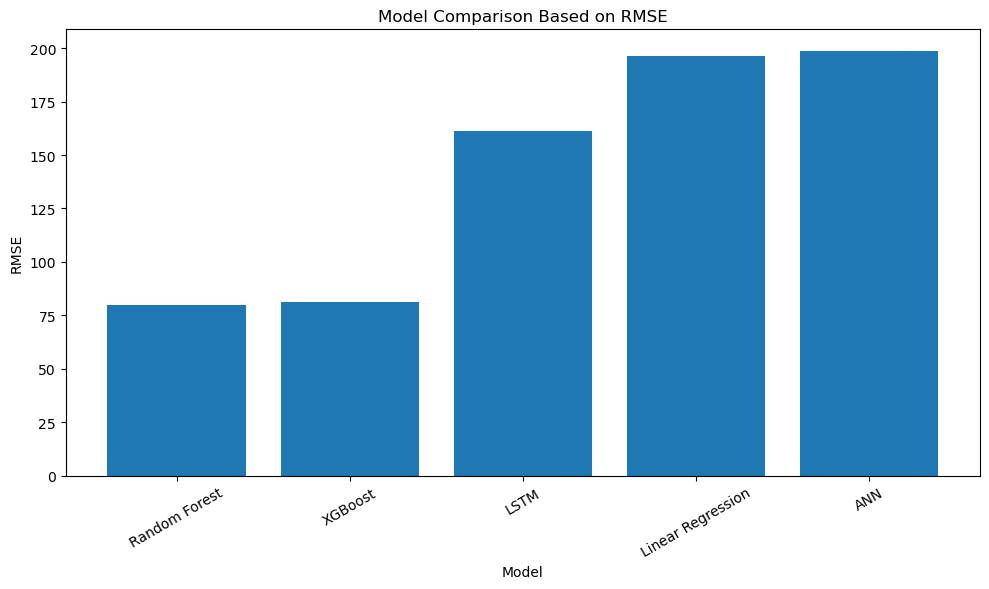

In [89]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [90]:
import pickle

# Save LSTM model
model_lstm.save("pjm_lstm_model.keras")

# Save the scaler
with open("lstm_scaler.pkl", "wb") as file:
    pickle.dump(scaler_lstm, file)

print("LSTM model and scaler saved successfully.")

LSTM model and scaler saved successfully.


In [1]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.21.0
Keras: 3.15.0


In [1]:
!jupyter nbconvert --to script "PJMW_MW_HOURLY_PREDICTIONS.ipynb"

[NbConvertApp] Converting notebook PJMW_MW_HOURLY_PREDICTIONS.ipynb to script
[NbConvertApp] Writing 26347 bytes to PJMW_MW_HOURLY_PREDICTIONS.py
